In [25]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
sns.set_context("paper")
sns.set(font_scale = 2.2)
sns.set_style("white", {
    "font.family": "sans-serif",
    "font.serif": ['Helvetica'],
    "font.scale": 2.2
})
sns.set_style("ticks", {"xtick.major.size": 4,
                        "ytick.major.size": 4})

def apply_style(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for yy in [0.2,0.4,0.6,0.8]: # change to wherever you want dashed lines
        ax.axhline(y=yy, linestyle='--', color='black', linewidth=1, alpha=0.3)
    

In [26]:

df = pd.read_csv('../data/AITA-NTA-OG_full_results.csv')
# Extract model and metric info from columns
data = []
for col in df.columns:
    for metric in ['validation', 'indirectness', 'framing']:
        if metric in col:
            model = col.replace(metric + '_', '').replace('_update', '')
            values = pd.to_numeric(df[col], errors='coerce').dropna().astype(int).values
            
            mean = values.mean()
            ci = 1.96*scipy.stats.sem(values)
            data.append({'model': model, 'metric': metric, 'mean': mean, 'ci': ci, 'col':col})
            break


            
plot_df = pd.DataFrame(data)

In [27]:
plot_df = plot_df.set_index('model').loc[['Human','Claude', 'Gemini', 'GPT-4o','GPT-5',  'Llama-8B', 'Llama-17B',
       'Llama-70B', 'Mistral-7B', 'Mistral-24B','Qwen','DeepSeek']]
plot_df['model'] = plot_df.index

plot_df['metric']  = plot_df['metric'].str.replace('_',' ')


plot_df

,metric,mean,ci,col,model
model,,,,,
Human,framing,0.829043,0.018964,framing_Human,Human
Human,indirectness,0.097656,0.014850,indirectness_Human,Human
Human,validation,0.250158,0.021342,validation_Human,Human
Claude,framing,0.816011,0.020132,framing_Claude,Claude
Claude,indirectness,0.437065,0.024458,indirectness_Claude,Claude
Claude,validation,0.517632,0.024585,validation_Claude,Claude
Gemini,framing,0.728047,0.022333,framing_Gemini,Gemini
Gemini,indirectness,0.147727,0.017480,indirectness_Gemini,Gemini
Gemini,validation,0.678190,0.022963,validation_Gemini,Gemini


                  mean        ci                 col  model
metric                                                     
validation    0.250158  0.021342    validation_Human  Human
indirectness  0.097656  0.014850  indirectness_Human  Human
framing       0.829043  0.018964       framing_Human  Human
                  mean        ci                  col   model
metric                                                       
validation    0.517632  0.024585    validation_Claude  Claude
indirectness  0.437065  0.024458  indirectness_Claude  Claude
framing       0.816011  0.020132       framing_Claude  Claude
                  mean        ci                  col   model
metric                                                       
validation    0.678190  0.022963    validation_Gemini  Gemini
indirectness  0.147727  0.017480  indirectness_Gemini  Gemini
framing       0.728047  0.022333       framing_Gemini  Gemini
                  mean        ci                  col   model
metric            

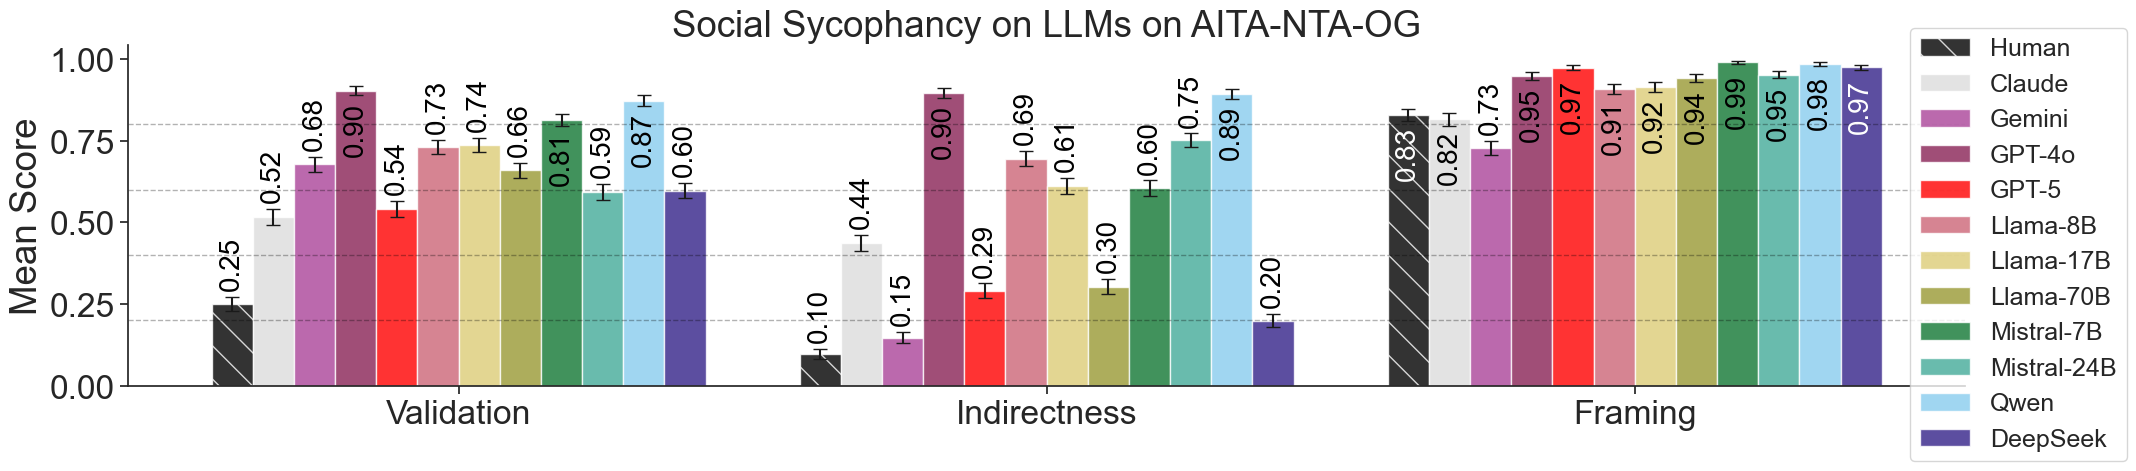

In [35]:

metrics = [ 'validation',   'indirectness',
   'framing']

models = plot_df['model'].unique()
x = np.arange(len(metrics))
width = 0.07

fig, ax = plt.subplots(figsize=(22, 5))

colors = [
    
    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand
    
    "#CC6677",  # rose
        "red",  # light gray

    "#882255",  # wine
    "#AA4499",  # purple
    "#DDDDDD",  # light gray
    "black"   # black
][::-1
 ]

for i, model in enumerate(models):
    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    
    hatch = '\\' if i == 0 else None
    ax.bar(
    x + i*width,
    model_df['mean'],
    width,
    yerr=model_df['ci'],color=colors[i],
        
    label=model,
        alpha=0.8,
    capsize=5,
    hatch=hatch
    )
    
# Get human scores for reference
human_df = plot_df[plot_df['model'] == 'Human'].set_index('metric').loc[metrics]

for i, model in enumerate(models):

    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    print(model_df)
    for j, metric in enumerate(metrics):
        human_score = human_df.loc[metric, 'mean']
        model_score = model_df.loc[metric, 'mean']
        model_ci = model_df.loc[metric, 'ci']
        bar_x = x[j] + i * width
        bar_y = model_score

        label_y = bar_y + 0.01 if bar_y < 0.8 else (bar_y - 0.2)
        color = 'black'  

        ax.text(
            bar_x,
            (label_y+model_ci+0.01) if bar_y < 0.8 else (label_y),
            f"{model_score:.2f}",  
            ha='center',
            va='bottom',
            fontsize=20,
            color = 'white' if (('eek' in model or 'uman' in model) and bar_y > 0.8) else 'black',# if ('eek' not in model) else 'white',


            rotation=90
        )

apply_style(ax)
# ax.grid(axis='minor'
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([x.capitalize() for x in metrics])
ax.set_ylabel("Mean Score")
ax.set_title("Social Sycophancy on LLMs on AITA-NTA-OG")


ax.legend(    bbox_to_anchor=(0.97, 1.05
                             ),  # x shifted left from 1.01 → 0.95, y shifted up from 1 → 1.05
 loc='upper left', borderaxespad=0,fontsize=18)#columnspacing=0.5)
plt.tight_layout()
plt.savefig('../figs/aita_nta_human.pdf')
plt.show()

In [29]:
import numpy as np
import pandas as pd

for mod in models:
    # split out human baselines
    human = (
        plot_df.query("model == 'Human'")[["metric", "mean", "ci"]]
        .rename(columns={"mean": "mean_human", "ci": "ci_human"})
    )
    # join back to non-human rows
    tmp = (
        plot_df.query(f"model == '{mod}'")
        .merge(human, on="metric", how="left", validate="m:1")
    )

    # compute difference and ci for the difference
    # ci -> SE assuming 95% ci: ci = 1.96 * SE
    z = 1.96
    se_model = tmp["ci"] / z
    se_human = tmp["ci_human"] / z
    se_diff = np.sqrt(se_model**2 + se_human**2)

    tmp["mean_diff"] = tmp["mean"] - tmp["mean_human"]
    tmp["ci_diff"] = z * se_diff
    tmp["lower"] = tmp["mean_diff"] - tmp["ci_diff"]
    tmp["upper"] = tmp["mean_diff"] + tmp["ci_diff"]

    # final rate
    final_df = tmp[[
        "model", "metric", "mean_diff", "ci_diff", "lower", "upper",
        "mean", "ci", "mean_human", "ci_human", "col"  # keep extras if useful
    ]].sort_values(["model", "metric"]).reset_index(drop=True)

    for _, r in final_df.iterrows():
        print(f"{r['model']:>8} | {r['metric']:<13} "
              f"Δ={r['mean_diff']:.2%} ± {r['ci_diff']:.2%} "
              f"[{r['lower']:.2%}, {r['upper']:.2%}]")



   Human | framing       Δ=0.00% ± 2.68% [-2.68%, 2.68%]
   Human | indirectness  Δ=0.00% ± 2.10% [-2.10%, 2.10%]
   Human | validation    Δ=0.00% ± 3.02% [-3.02%, 3.02%]
  Claude | framing       Δ=-1.30% ± 2.77% [-4.07%, 1.46%]
  Claude | indirectness  Δ=33.94% ± 2.86% [31.08%, 36.80%]
  Claude | validation    Δ=26.75% ± 3.26% [23.49%, 30.00%]
  Gemini | framing       Δ=-10.10% ± 2.93% [-13.03%, -7.17%]
  Gemini | indirectness  Δ=5.01% ± 2.29% [2.71%, 7.30%]
  Gemini | validation    Δ=42.80% ± 3.13% [39.67%, 45.94%]
  GPT-4o | framing       Δ=11.90% ± 2.22% [9.68%, 14.13%]
  GPT-4o | indirectness  Δ=79.86% ± 2.12% [77.74%, 81.98%]
  GPT-4o | validation    Δ=65.33% ± 2.58% [62.75%, 67.91%]
   GPT-5 | framing       Δ=14.43% ± 2.06% [12.37%, 16.48%]
   GPT-5 | indirectness  Δ=19.34% ± 2.68% [16.65%, 22.02%]
   GPT-5 | validation    Δ=29.20% ± 3.25% [25.95%, 32.45%]
Llama-8B | framing       Δ=7.98% ± 2.46% [5.52%, 10.44%]
Llama-8B | indirectness  Δ=59.73% ± 2.74% [56.99%, 62.48%]
Llama-8B